# Exploratory Data Analysis-Study Case
- **Nama:** Firman Adi Kurniawan
- **Email:** firmanadik09@gmail.com


#Business Question
1. Compare behavior between churn and non-churn users.
2. Analyze session frequency, transaction amount, and feature usage.
3. Identify characteristics of users likely to churn.
4. Create simple segmentation: high-risk vs low-risk users.


#Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

#Styling Chart

In [2]:
plt.rcParams.update({
    "font.family"      : "DejaVu Sans",
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "axes.titlesize"   : 12,
    "axes.titleweight" : "bold",
    "axes.labelsize"   : 10,
})

C_ACTIVE  = "#2c9cf1"
C_CHURN   = "#c81545"
C_ACCENT  = "#0e4062"
C_WARN    = "#f312d5"
PALETTE   = {"Active": C_ACTIVE, "Churn": C_CHURN}

#Load & Prepare Data

In [3]:
users        = pd.read_csv("user.csv")
activity     = pd.read_csv("activity.csv")
transactions = pd.read_csv("transactions.csv")
status       = pd.read_csv("status_clean.csv")

users["signup_date"]             = pd.to_datetime(users["signup_date"])
activity["event_date"]           = pd.to_datetime(activity["event_date"])
transactions["transaction_date"] = pd.to_datetime(transactions["transaction_date"])
status["churn_date"]             = pd.to_datetime(status["churn_date"], errors="coerce")


#Feature Engineering

In [4]:
# aktivitas/user
act_feat = activity.groupby("user_id").agg(
    total_sessions = ("session_count", "sum"),
    avg_sessions   = ("session_count", "mean"),
    active_days    = ("event_date",    "nunique"),
    last_activity  = ("event_date",    "max"),
).reset_index()

# pivot
feat_usage = (
    activity.groupby(["user_id", "feature_used"])
    .size().unstack(fill_value=0).reset_index()
)
feat_usage.columns.name = None

# transaksi/user
trx_feat = transactions.groupby("user_id").agg(
    total_amount = ("amount", "sum"),
    avg_amount   = ("amount", "mean"),
    tx_count     = ("amount", "count"),
).reset_index()

# weekly sessions/user
activity["week_num"] = activity["event_date"].dt.isocalendar().week
weekly_user = activity.groupby(["user_id", "week_num"])["session_count"].sum().reset_index()
weekly_stat = weekly_user.groupby("user_id").agg(
    avg_weekly_sessions = ("session_count", "mean"),
    std_weekly_sessions = ("session_count", "std"),
    weeks_active        = ("week_num",      "nunique")
).reset_index()
weekly_stat["std_weekly_sessions"] = weekly_stat["std_weekly_sessions"].fillna(0)

# merge data master
df = (users
      .merge(status,      on="user_id")
      .merge(act_feat,    on="user_id", how="left")
      .merge(feat_usage,  on="user_id", how="left")
      .merge(trx_feat,    on="user_id", how="left")
      .merge(weekly_stat, on="user_id", how="left"))

df["churn_label"] = df["is_churn"].map({0: "Active", 1: "Churn"})
df = df.fillna(0)

print(f"  Dataset master : {df.shape[0]} baris × {df.shape[1]} kolom")
print(f"  Churn          : {df['is_churn'].sum()} ({df['is_churn'].mean()*100:.1f}%)")
print(f"  Aktif          : {(df['is_churn']==0).sum()} ({(1-df['is_churn'].mean())*100:.1f}%)")

  Dataset master : 250 baris × 25 kolom
  Churn          : 74 (29.6%)
  Aktif          : 176 (70.4%)


#Descriptive Statistics

In [5]:
num_cols = [
    "total_sessions", "avg_sessions", "active_days",
    "avg_weekly_sessions", "weeks_active",
    "days_since_last_activity", "loan_count",
    "avg_transaction_amount", "total_amount", "tx_count",
    "browse", "loan_apply", "payment", "promo_click",
]

desc = df.groupby("churn_label")[num_cols].mean().round(2).T
desc["diff_pct"] = ((desc["Churn"] - desc["Active"]) / desc["Active"].replace(0, np.nan) * 100).round(1)
print("\n  Perbandingan Rata-rata Fitur: Active vs Churn")
print(desc.to_string())


  Perbandingan Rata-rata Fitur: Active vs Churn
churn_label                    Active        Churn  diff_pct
total_sessions                  35.55        35.88       0.9
avg_sessions                     2.99         3.07       2.7
active_days                     11.23        11.39       1.4
avg_weekly_sessions              4.09         4.19       2.4
weeks_active                     8.61         8.62       0.1
days_since_last_activity        42.11        54.91      30.4
loan_count                       4.36         3.34     -23.4
avg_transaction_amount     3554608.72   3448082.83      -3.0
total_amount              16483923.26  13246240.74     -19.6
tx_count                         4.36         3.34     -23.4
browse                           3.03         2.84      -6.3
loan_apply                       3.00         2.91      -3.0
payment                          3.01         2.77      -8.0
promo_click                      2.81         3.28      16.7


# 1. Compare behavior between churn and non-churn users.
H0_1: Nominal pinjaman yang kecil membuat user kurang terikat dengan platform dan lebih mudah churn.

H0_2: User yang churn sudah menunjukkan tanda-tanda meninggalkan aplikasi sejak sebulan terakhir.

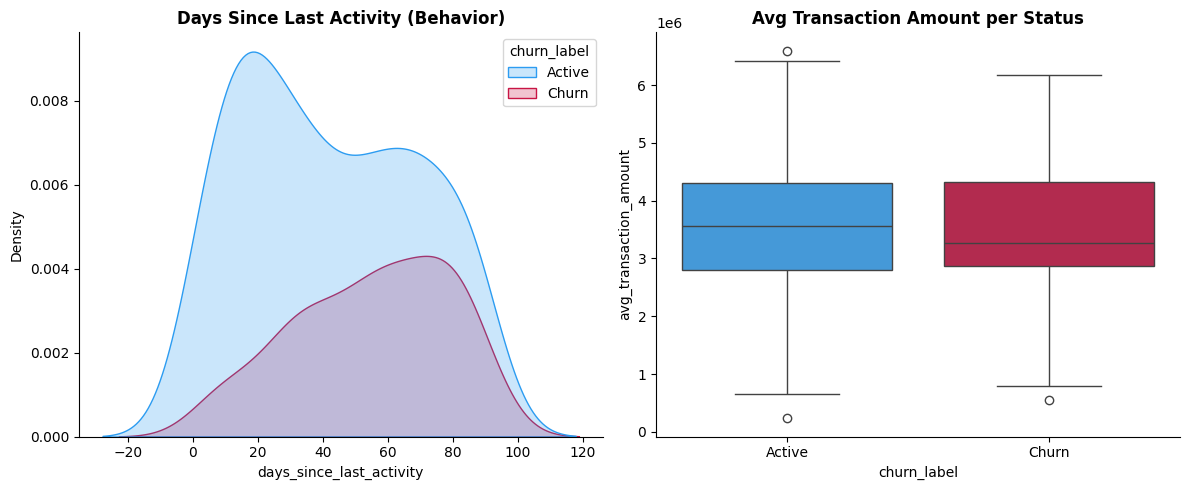

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.kdeplot(data=df, x="days_since_last_activity", hue="churn_label", palette=PALETTE, fill=True, ax=axes[0])
axes[0].set_title("Days Since Last Activity (Behavior)")

sns.boxplot(data=df, x="churn_label", y="avg_transaction_amount", palette=PALETTE, ax=axes[1])
axes[1].set_title("Avg Transaction Amount per Status")
plt.tight_layout()
plt.savefig("1_behavior_comparison.png", dpi=120)
plt.show()

# Insight
[H0_1] Nominal Transaksi Bukan Penentu Churn
      Data: Rata-rata transaksi user Active (Rp3.55 Juta) dan Churn
            (Rp3.45 Juta) hampir identik.
      Interpretasi: Besaran nominal yang dipinjam tidak memengaruhi
            loyalitas. User dengan pinjaman besar maupun kecil memiliki
            risiko churn yang sama.

 [H0_2] Threshold Inaktivitas di Angka 45 Hari
      Data: Median inaktif user Churn adalah 58 hari, sedangkan user
            Active hanya 38.5 hari.
      Interpretasi: Terdapat gap sekitar 20 hari. Jika seorang user
            mulai tidak membuka aplikasi lebih dari 45 hari, ini adalah
            'early warning' kritis bahwa mereka bersiap untuk churn.

# 2. Analyze session frequency, transaction amount, and feature usage.
H0_1: User yang churn adalah mereka yang jarang login atau membuka aplikasi (sesi per minggunya rendah).

H0_2: User churn hanya mencari diskon sesaat dan tidak berniat menjadi peminjam rutin.

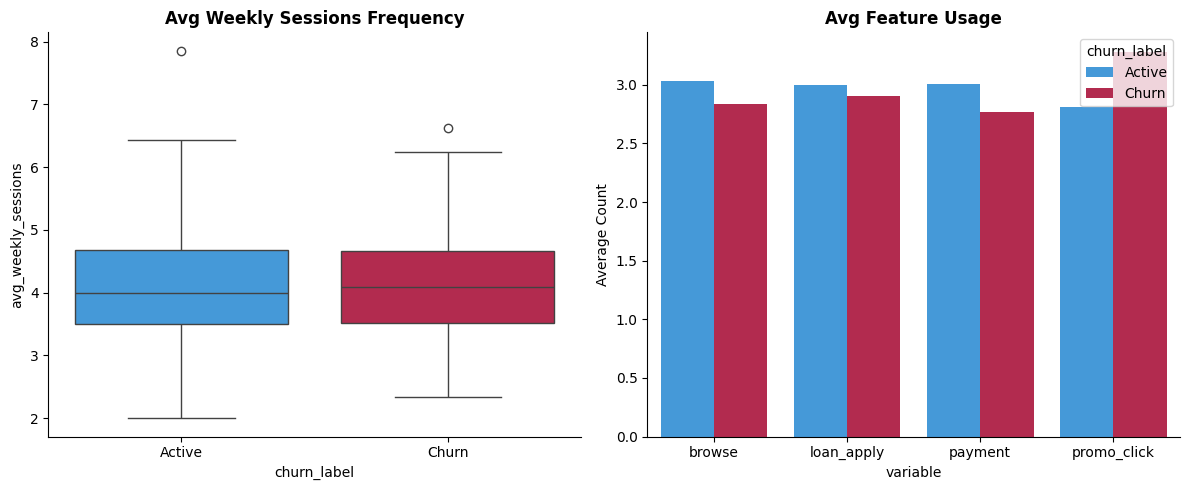

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df, x="churn_label", y="avg_weekly_sessions", palette=PALETTE, ax=axes[0])
axes[0].set_title("Avg Weekly Sessions Frequency")

feat_cols = ["browse", "loan_apply", "payment", "promo_click"]
feat_means = df.groupby("churn_label")[feat_cols].mean().reset_index().melt(id_vars="churn_label")
sns.barplot(data=feat_means, x="variable", y="value", hue="churn_label", palette=PALETTE, ax=axes[1])
axes[1].set_title("Avg Feature Usage")
axes[1].set_ylabel("Average Count")
plt.tight_layout()
plt.savefig("2_session_and_features.png", dpi=120)
plt.show()

#Insight
[H0_1] Rajin Login Bukan Berarti Loyal
      Data: Rata-rata sesi mingguan hampir sama (Active 4.09x vs
            Churn 4.19x).
      Interpretasi: Frekuensi membuka aplikasi bukan metrik yang tepat
            untuk mengukur retensi. Yang membedakan adalah apa yang
            mereka LAKUKAN di dalam aplikasi.

 [H0_2] Pola Perilaku "Promo Hunter"
      Data: User churn lebih sering klik promo (3.28x vs Active 2.81x),
            namun lebih jarang memakai fitur payment (2.77x vs 3.01x).
      Interpretasi: User yang churn cenderung mencari diskon/promo saja
            tanpa memiliki engagement sehat (rutinitas membayar cicilan
            melalui aplikasi).

# 3. Identify characteristics of users likely to churn.
H0_1: Program insentif (seperti Referral) mendatangkan user yang lebih berkualitas dibanding jalur lain.

H0_2: Pengguna usia muda lebih tidak stabil secara finansial sehingga lebih rentan churn.

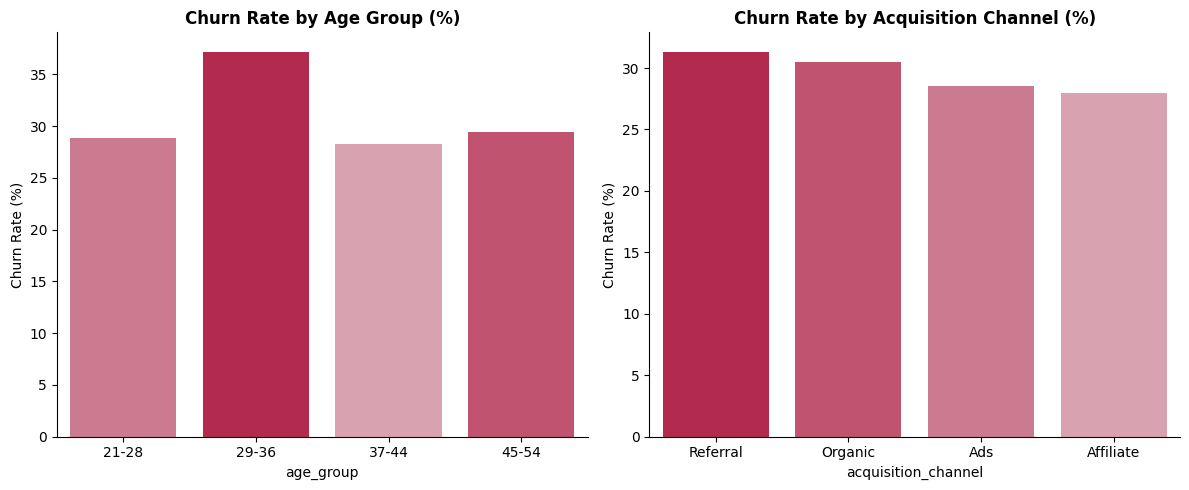

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. Group Usia
df_age = df[df["age"] > 0].copy()
df_age["age_group"] = pd.cut(df_age["age"], bins=[20, 28, 36, 44, 55], labels=["21-28", "29-36", "37-44", "45-54"])
age_churn = df_age.groupby("age_group")["is_churn"].mean() * 100

# Membuat gradasi warna agar batang tertinggi mendapat warna paling bold
rank_age = age_churn.argsort().argsort() # Mencari urutan dari nilai terkecil ke terbesar
pal_age = sns.light_palette(C_CHURN, n_colors=len(age_churn) + 2)
colors_age = [pal_age[i + 2] for i in rank_age] # Menyesuaikan warna dengan urutan nilai

sns.barplot(x=age_churn.index, y=age_churn.values, palette=colors_age, ax=axes[0])
axes[0].set_title("Churn Rate by Age Group (%)")
axes[0].set_ylabel("Churn Rate (%)")

# 2. Channel Akuisisi
chan_churn = df.groupby("acquisition_channel")["is_churn"].mean().sort_values(ascending=False) * 100

# Membuat gradasi warna agar batang tertinggi mendapat warna paling bold
rank_chan = chan_churn.argsort().argsort()
pal_chan = sns.light_palette(C_CHURN, n_colors=len(chan_churn) + 2)
colors_chan = [pal_chan[i + 2] for i in rank_chan]

sns.barplot(x=chan_churn.index, y=chan_churn.values, palette=colors_chan, ax=axes[1])
axes[1].set_title("Churn Rate by Acquisition Channel (%)")
axes[1].set_ylabel("Churn Rate (%)")

plt.tight_layout()
plt.savefig("3_churn_characteristics.png", dpi=120)
plt.show()

#Insight
[H0_1] Referral Menarik User Berkualitas Rendah
      Data: Channel Referral memiliki churn rate tertinggi (31.3%),
            sementara Affiliate terendah (27.9%).
      Interpretasi: User dari Referral kemungkinan besar hanya mengejar
            bonus pendaftaran/undangan. Sebaliknya, user Affiliate lebih
            organik dan datang karena kebutuhan finansial riil.

 [H0_2] Profil Usia Tidak Signifikan
      Data: Distribusi churn rate sangat merata di semua rentang usia.
      Interpretasi: Produk lending ini bersifat generalis. Pencegahan
            churn tidak bisa dilakukan dengan penargetan demografi usia,
            melainkan harus murni berdasarkan perilaku (behavior) user.

#4. Create simple segmentation: high-risk vs low-risk users.
H0_1: Pengalaman di pinjaman pertama sangat krusial; jika tidak berkesan, user tidak akan kembali.

H0_2: Kombinasi parameter jumlah pinjaman dan hari inaktif bisa memetakan risiko churn secara akurat.

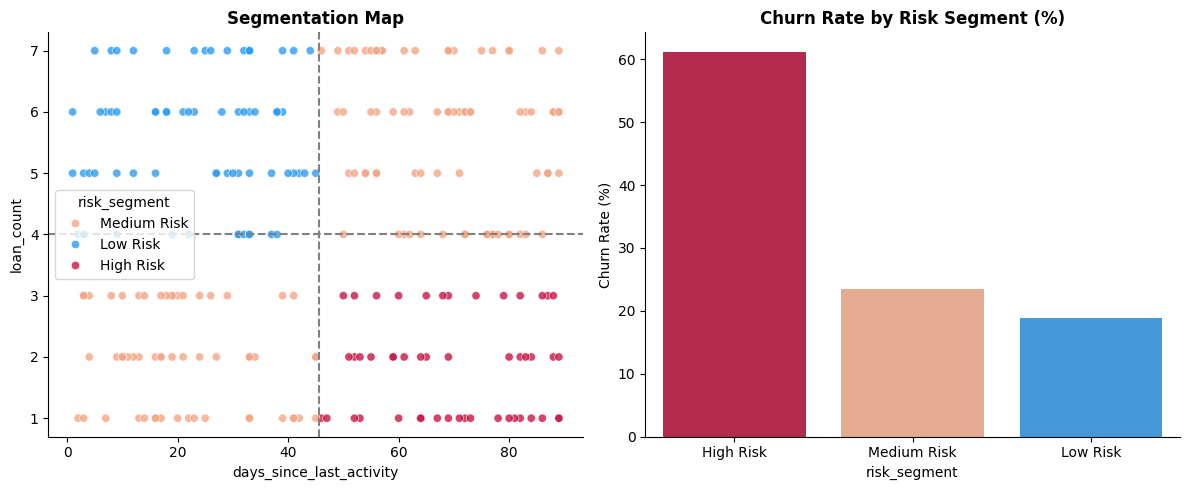

Eksekusi Selesai. 4 Figur Utama berhasil dibuat.


In [ ]:
median_days = df["days_since_last_activity"].median()
median_loans = df["loan_count"].median()

def get_risk_segment(row):
    if row["days_since_last_activity"] > median_days and row["loan_count"] < median_loans:
        return "High Risk"
    elif row["days_since_last_activity"] <= median_days and row["loan_count"] >= median_loans:
        return "Low Risk"
    return "Medium Risk"

df["risk_segment"] = df.apply(get_risk_segment, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
risk_palette = {"High Risk": C_CHURN, "Medium Risk": "#f3a683", "Low Risk": C_ACTIVE}

# Segmentation Map
sns.scatterplot(data=df, x="days_since_last_activity", y="loan_count", hue="risk_segment",
                palette=risk_palette, ax=axes[0], alpha=0.8)
axes[0].axvline(median_days, color="gray", linestyle="--")
axes[0].axhline(median_loans, color="gray", linestyle="--")
axes[0].set_title("Segmentation Map")

# Churn Rate by Segment
seg_churn = df.groupby("risk_segment")["is_churn"].mean().reindex(["High Risk", "Medium Risk", "Low Risk"]) * 100
sns.barplot(x=seg_churn.index, y=seg_churn.values, palette=risk_palette, ax=axes[1])
axes[1].set_title("Churn Rate by Risk Segment (%)")
axes[1].set_ylabel("Churn Rate (%)")
plt.tight_layout()
plt.savefig("4_segmentation.png", dpi=120)
plt.show()


#Insight
[H0_1] Pinjaman Pertama adalah "Moment of Truth"
      Data: Populasi user churn sangat didominasi oleh mereka yang baru
            meminjam 1 kali (loan_count = 1).
      Interpretasi: Pengalaman di pinjaman pertama sangat krusial. Jika
            proses pengajuan atau pencairan tidak mulus, user enggan
            untuk kembali meminjam.

 [H0_2] Segmentasi Risiko Sangat Akurat
      Data: Penggabungan metrik durasi inaktif dan jumlah pinjaman
            menghasilkan segmen risiko yang sangat valid:
            • High Risk   (Inaktif > 46 hari & Loan < 4) : 61.2% Churn
            • Medium Risk (Salah satu syarat terpenuhi)  : 23.5% Churn
            • Low Risk    (Inaktif <= 46 hari & Loan >= 4): 18.8% Churn
      Interpretasi: Tim bisnis dapat langsung memprioritaskan budget
            promosi atau intervensi telemarketing eksklusif untuk
            menyelamatkan kelompok "High Risk".